# Week 6

[Good news everyone!](https://www.youtube.com/watch?v=vLxMB8xmWSI) We've had heavy exercise load the last few weeks, so it's time for an lighter day today `:)`

The purpose of today's class is to explore data using **interactive visualizations**. Interactivity is a key part of modern dataviz. It lets users of your visualizations get their own feel for the data, creating richer experiences where people can expose more of the data by exploring.

## Today

This lecture covers:

1. **Explanatory data visualization**: A video lecture on the principles of interactive, explanatory dataviz: overview first, zoom and filter, details on demand.
2. **Interactive visualizations with Plotly**: You'll rebuild the hourly crime distributions from Week 2 as interactive plots, and then take things further with animated visualizations.
3. **Narrative data visualization**: Reading from a key research paper on how to tell stories with data.

## Part 1: Explanatory Data Visualization

Starting this week, we'll be playing around with *explanatory data visualization*. Roughly speaking, this means using data visualization to communicate your results to others. Thus, there are new things to think about.

Until today we have worked with static data visualization. However, exploratory data analysis means being able to explore the multi-faceted nature of data, and *interactive dataviz* is a handy tool to do it! It allows the user to play with the data without knowing how to write code: toggle the view, zoom, drag, show more details. These are a key part of modern data visualization.

The video below provides context about these points.

We start with the video and then read a bit from a scientific article about types of explanatory dataviz. (*The video is from an old version of the class that used D3, so just ignore those parts.*)

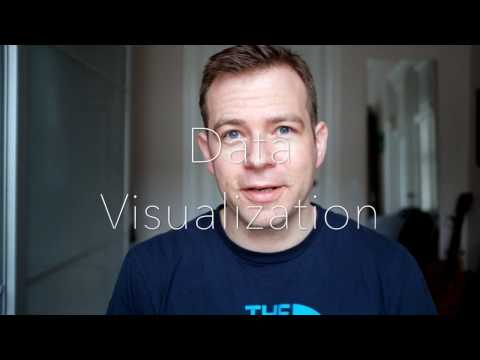

In [1]:
from IPython.display import YouTubeVideo
YouTubeVideo('yHKYMGwefso', width=800, height=450)

> *Exercise 1.1*: Explanatory data visualization.
> * What are the three key elements to keep in mind when you design an explanatory visualization?
> * In the video I talk about (1) *overview first*, (2) *zoom and filter*, (3) *details on demand*.
>   - Go online and find a visualization that follows these principles (don't use one from the video).
>   - Explain how your example achieves (1)-(3). It might be useful to use screenshots to illustrate your explanation.
> * Explain in your own words: How is explanatory data analysis different from exploratory data analysis?
>
> **Note**. Keep your answers to the questions above short and sweet.

<div class="alert alert-block alert-info">
Try to answer these using your human brain, don't use an LLM.
</div>

## Part 2: Interactive Visualizations with Plotly

You already know Plotly from Week 5, where you used it to create choropleth maps. Now we'll use it for a different purpose: building interactive charts that let users explore temporal patterns in the crime data.

Plotly is great for this because it gives you interactivity for free: hover tooltips, zoom, pan, and clickable legends all come built-in. This means you can focus on the *data* and the *story*, not on wiring up interactive widgets.

If you need a refresher, the [Plotly Express documentation](https://plotly.com/python/plotly-express/) is a good starting point. But I hope you'll find that you remember more from Week 5 than you think 🤟

**Note**: There are many other ways to create interactive visualizations. I'll highlight two

* *[Altair](https://altair-viz.github.io/)*
* *[Bokeh](https://docs.bokeh.org/en/latest/)* (Bokeh is nice when you want a bit more lower-level control in Python, we've used this in the class previously).

If you want to use these when we get further in the class and you're creating your  own visualizations in the final project, that is OK.

Anyway. **Let's get started**. As always we'll focus on the SF crime data, and your personal focus crimes. Data for whole years only.

The goal is to create an *interactive* visualization of how your Personal Focus Crimes distribute across the 24 hours of the day — similar to what you plotted in Week 2's Exercise 3.1, but now set up so the user can play with the data. The key feature: you can click on crime types in the legend to show and hide them, making it possible to directly compare patterns across crime types.

> *Exercise 2.1*: New version weekly patterns. To complete the exercise, follow the steps below.

<div class="alert alert-block alert-info">
Try to do this yourself before asking an LLM — you already know Plotly from Week 5, and the data preparation is similar to what you did in Week 2. Use your LLM as a helper if you get stuck, not as an end-to-end solution.
</div>

> ### Data prep
>
> A key step is to set up the data right. I recommend the following workflow:
>
> 1. Take the data for the period you want to plot, group it by hour-of-the-day for each of your Personal Focus Crimes. We'll use the entire period by default, but you may use another period if you'd like.
> 2. We want to compare *shapes* of distributions across crime types, not absolute numbers, so we'll work on **normalized data**:
>    * To normalize within a crime category, divide the count for each hour by the total number of that crime type. (For example, in the `Drug Offense` category, take the count of drug offenses in the midnight-to-1am hour and divide by the total number of drug offenses across all hours, etc)
>    * Note that when you normalize the data, you can interpret your data as a probability distribution, where each hour shows the probability that a crime will happen at that time.
>    * Your life will be easiest if you organize your data in **long format** — a DataFrame with columns like `Hour`, `CrimeType`, and `NormalizedCount`. If you have it in wide format (one column per crime type), look into [`pd.melt()`](https://pandas.pydata.org/docs/reference/api/pandas.melt.html) to reshape it.
>
> ### Creating the plot
>
> You'll use `px.bar` from Plotly Express — the same library you used for choropleth maps in Week 5. A few things to think about:
>
> * With many crime types, placing bars side-by-side for each hour produces tiny, unreadable bars. Look into Plotly's different [`barmode`](https://plotly.com/python/bar-charts/) options for a better approach. Adding some transparency will help when bars overlap.
> * The plot is more useful if it starts "empty" (all data/traces hidden) so the user can build up comparisons by clicking legend items one at a time. Look into Plotly's `visible` trace property to achieve this.
> * If all traces start hidden, Plotly has no data to auto-scale from, so your axes will not be meaningful. You'll need to set `range_x` and `range_y` explicitly. Think about what sensible values would be for 24 hours of data with normalized counts.
> * Place the legend where it doesn't obscure the data or the axis tick values. <font color=gray>It's OK to ask your LLM for help with legend placement.</font>
>
> It's hard to explain what I'm looking for, so here's my version so you have an idea. You plot doesn't have to look exactly like that, it's just so you have a sense of what I'm looking for and a picture's worth 1000 words.
> 
> ![example gif](https://raw.githubusercontent.com/suneman/socialdata2026/main/files/example.gif)
> 
> ### Think about your beautiful creation
>
> 3. Try clicking on the crime types in the legend. Try single-clicking (toggles one trace) and double-clicking (isolates one trace). 
> 4. Hover over the bars — what information does the tooltip show?
> 5. Comment on what you see:
>    * Which crime types peak at similar hours? Which ones have very different patterns?
>    * Does anything surprise you compared to what you saw in Week 2?
>    * How does the interactivity (toggling, hovering, zooming) change your experience of exploring this data compared to the static plots from Week 2?

### Exercise 2.1 — Interactive hourly crime distributions

Use the legend to explore the patterns:
- **Single-click** a crime type to toggle it on/off
- **Double-click** a legend item to isolate that crime type
- **Hover** bars to read exact normalized values

#### Short comments (replace with your own observations)
- Crime types with similar peaks: _..._
- Crime types with very different patterns: _..._
- Surprises vs Week 2: _..._
- How interactivity changed the analysis experience: _..._

In [2]:
from pathlib import Path
import numpy as np
import pandas as pd
import plotly.express as px

# --------------------------
# 1) Load and harmonize data
# --------------------------
root = Path.cwd().resolve().parent
hist_path = root / "Week2" / "Police_Department_Incident_Reports__Historical_2003_to_May_2018_20260210.csv"
recent_path = root / "Week1" / "Police_Department_Incident_Reports__2018_to_Present_20260203.csv"

hist = pd.read_csv(hist_path)
recent = pd.read_csv(recent_path)

hist_renamed = hist.rename(columns={"Date": "Incident Date", "Time": "Incident Time", "Category": "CategoryRaw"})
recent_renamed = recent.rename(columns={"Incident Date": "Incident Date", "Incident Time": "Incident Time", "Incident Category": "CategoryRaw"})

common_cols = ["Incident Date", "Incident Time", "CategoryRaw"]
df = pd.concat([hist_renamed[common_cols], recent_renamed[common_cols]], ignore_index=True)

# --------------------------
# 2) Map to personal focus crimes
# --------------------------
focus_crimes_mapping = {
    "Assault": {"historical": "ASSAULT", "recent": ["ASSAULT"]},
    "Burglary": {"historical": "BURGLARY", "recent": ["BURGLARY"]},
    "Robbery": {"historical": "ROBBERY", "recent": ["ROBBERY"]},
    "Vehicle Theft": {"historical": "VEHICLE THEFT", "recent": ["MOTOR VEHICLE THEFT", "MOTOR VEHICLE THEFT?", "VEHICLE THEFT"]},
    "Larceny/Theft": {"historical": "LARCENY/THEFT", "recent": ["LARCENY THEFT"]},
    "Drug Offense": {"historical": "DRUG/NARCOTIC", "recent": ["DRUG OFFENSE", "DRUG VIOLATION"]},
    "Vandalism": {"historical": "VANDALISM", "recent": ["VANDALISM"]},
    "Fraud": {"historical": "FRAUD", "recent": ["FRAUD"]},
    "Weapons Offense": {"historical": "WEAPON LAWS", "recent": ["WEAPON OFFENSE"]},
}

# Optional: choose a subset/order here
selected_focus_crimes = [
    "Assault",
    "Burglary",
    "Robbery",
    "Vehicle Theft",
    "Larceny/Theft",
    "Drug Offense",
    "Vandalism",
    "Fraud",
    "Weapons Offense",
]

# Build reverse lookup from raw labels -> unified crime label
label_lookup = {}
for crime_label, mapping in focus_crimes_mapping.items():
    label_lookup[mapping["historical"]] = crime_label
    for rc in mapping["recent"]:
        label_lookup[rc] = crime_label

df["CategoryRaw"] = df["CategoryRaw"].astype(str).str.strip().str.upper()
df["CrimeType"] = df["CategoryRaw"].map(label_lookup)

plot_df = df[df["CrimeType"].isin(selected_focus_crimes)].copy()

# --------------------------
# 3) Hour extraction + normalization (long format)
# --------------------------
plot_df["Incident Date"] = pd.to_datetime(plot_df["Incident Date"], errors="coerce")
plot_df = plot_df.dropna(subset=["Incident Date", "Incident Time", "CrimeType"])

plot_df["Hour"] = pd.to_numeric(plot_df["Incident Time"].astype(str).str.slice(0, 2), errors="coerce")
plot_df = plot_df[plot_df["Hour"].between(0, 23)]
plot_df["Hour"] = plot_df["Hour"].astype(int)

hourly_counts = (
    plot_df.groupby(["CrimeType", "Hour"]).size().rename("Count").reset_index()
)

# Ensure all 24 hours exist per crime (including zeros)
all_hours = pd.DataFrame({"Hour": np.arange(24)})
long_frames = []
for crime in selected_focus_crimes:
    one = hourly_counts[hourly_counts["CrimeType"] == crime][["Hour", "Count"]]
    one = all_hours.merge(one, on="Hour", how="left").fillna({"Count": 0})
    one["CrimeType"] = crime
    total = one["Count"].sum()
    one["NormalizedCount"] = one["Count"] / total if total > 0 else 0.0
    long_frames.append(one)

hourly_long = pd.concat(long_frames, ignore_index=True)[["Hour", "CrimeType", "NormalizedCount"]]

# --------------------------
# 4) Interactive Plotly bar chart
# --------------------------
max_y = float(hourly_long["NormalizedCount"].max())
y_upper = max(0.15, np.ceil((max_y + 0.01) * 100) / 100)

fig = px.bar(
    hourly_long,
    x="Hour",
    y="NormalizedCount",
    color="CrimeType",
    category_orders={"CrimeType": selected_focus_crimes},
    barmode="overlay",  # better readability with many categories
    opacity=0.55,
    title="Hourly distribution of Personal Focus Crimes (normalized)",
    labels={"Hour": "Hour of day", "NormalizedCount": "Probability within crime type"},
    hover_data={"CrimeType": True, "Hour": True, "NormalizedCount": ":.4f"},
)

# Start empty: user reveals traces via legend
fig.for_each_trace(lambda tr: tr.update(visible="legendonly"))

# Explicit axis ranges (important when all traces are hidden initially)
fig.update_xaxes(range=[-0.5, 23.5], dtick=1)
fig.update_yaxes(range=[0, y_upper], tickformat=".0%")

# Keep legend away from bars/axis labels
fig.update_layout(
    height=650,
    legend=dict(
        title="Crime type",
        orientation="v",
        x=1.02,
        xanchor="left",
        y=1,
        yanchor="top",
        bgcolor="rgba(255,255,255,0.8)",
    ),
    margin=dict(l=60, r=220, t=80, b=60),
)

fig.show()

print(f"Rows used: {len(plot_df):,}")
print(f"Crimes shown: {', '.join(selected_focus_crimes)}")

Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.


Rows used: 1,211,670
Crimes shown: Assault, Burglary, Robbery, Vehicle Theft, Larceny/Theft, Drug Offense, Vandalism, Fraud, Weapons Offense


> *Exercise 2.2*: Animated crime patterns.
>
> One of Plotly's powerful features is built-in animation. Let's use it to show how hourly crime patterns have changed over time.
>
> * Take the concept of normalized hourly distributions, but now compute one **separately for each year** (still for each of your Personal Focus Crimes).
>    * Take a look at the yearly counts. If some crime-types drop precipitously at some point, it might create noisy plots.
> * Create an animated **line chart** using Plotly Express's `animation_frame` parameter. Each frame should show one year's hourly distribution. Here's a sense of how to build the animation:
>
> ```python
> fig = px.line(your_dataframe, 
>              x='Hour', y='NormalizedCount', color='CrimeType',
>              animation_frame='Year',
>              title='Come up with an appropriate title!',
>              range_y=[0, 0.2])
> fig.show()
> ```
>
> * **Important**: Set `range_y` to fix the y-axis range across all frames. Without this, Plotly will auto-scale each frame independently, which makes it difficult/impossible to compare across years. (This is a real-world pitfall — animated charts that silently re-scale their axes can be deeply misleading. Remember the perceptual errors discussion from Week 5?)
> * With 9+ crime types on screen at once, the plot can get crowded. Consider starting with only one or two traces visible and letting the user toggle the rest on via the legend. You already know how to use `fig.update_traces(visible='legendonly')` — but for animated charts you'll also need to set visibility on each animation frame. <font color=gray>It's fine to ask your LLM how to do this.</font>
> * Hit play and watch the distributions evolve. Comment on what you see:
>   - Do any crime types shift their hourly pattern noticeably over the years?
>   - Can you spot the effect of COVID (2020-2021) on the patterns?
>   - Connecting to the note above: Do any crime types have distributions that become noticeably noisier in recent years? If so, why might that be?
> * Now try the same visualization as a **bar chart** instead of a line chart (hint: `px.bar` works with the same arguments, use `barmode='group'`). Which representation makes the temporal evolution easier to see — the animated lines or the animated bars? Why?
> * Reflect: is animation an effective way to explore this data, or would a different approach (e.g., small multiples — one static subplot per year) work better? What are the trade-offs?

<div class="alert alert-block alert-info">
It's OK to use your LLM for the code here. The observations and reflection should be your own.
</div>

In [3]:
# Exercise 2.2 — Animated crime patterns (yearly hourly distributions)

# Build year column from the cleaned dataframe created above
anim_df = plot_df.copy()
anim_df = anim_df.dropna(subset=["Incident Date", "Hour", "CrimeType"])
anim_df["Year"] = anim_df["Incident Date"].dt.year.astype(int)

# Quick diagnostic: yearly volume by crime type (helps identify noisy low-count tails)
yearly_counts = (
    anim_df.groupby(["Year", "CrimeType"])
    .size()
    .rename("Count")
    .reset_index()
    .sort_values(["Year", "CrimeType"])
)

print("Incidents per year and crime type (last 10 years):")
display(yearly_counts[yearly_counts["Year"] >= yearly_counts["Year"].max() - 9].pivot(index="Year", columns="CrimeType", values="Count").fillna(0).astype(int))

# Create a complete Year x CrimeType x Hour grid so all traces remain stable across frames
years = np.sort(anim_df["Year"].unique())
full_grid = pd.MultiIndex.from_product(
    [years, selected_focus_crimes, np.arange(24)],
    names=["Year", "CrimeType", "Hour"],
).to_frame(index=False)

hourly_year_counts = (
    anim_df.groupby(["Year", "CrimeType", "Hour"])
    .size()
    .rename("Count")
    .reset_index()
)

hourly_year = full_grid.merge(hourly_year_counts, on=["Year", "CrimeType", "Hour"], how="left")
hourly_year["Count"] = hourly_year["Count"].fillna(0)

# Normalize within each (Year, CrimeType)
hourly_year["NormalizedCount"] = hourly_year.groupby(["Year", "CrimeType"])["Count"].transform(
    lambda s: s / s.sum() if s.sum() > 0 else 0.0
)

max_y = float(hourly_year["NormalizedCount"].max())
y_upper = max(0.2, np.ceil((max_y + 0.01) * 100) / 100)

def set_initial_visibility(fig, visible_crimes):
    visible_set = set(visible_crimes)

    # Main traces
    for tr in fig.data:
        tr.visible = True if tr.name in visible_set else "legendonly"

    # Per-frame traces (required for animated charts)
    for fr in fig.frames:
        for tr in fr.data:
            tr.visible = True if tr.name in visible_set else "legendonly"

# Keep the chart readable by showing only 2 traces initially
initial_visible = selected_focus_crimes[:2]

# Animated line chart
fig_line = px.line(
    hourly_year,
    x="Hour",
    y="NormalizedCount",
    color="CrimeType",
    animation_frame="Year",
    category_orders={
        "CrimeType": selected_focus_crimes,
        "Year": years.tolist(),
    },
    labels={"Hour": "Hour of day", "NormalizedCount": "Probability within crime type"},
    title="How hourly crime distributions evolve by year (normalized within each crime type)",
    range_y=[0, y_upper],
)

set_initial_visibility(fig_line, initial_visible)
fig_line.update_xaxes(range=[-0.5, 23.5], dtick=1)
fig_line.update_yaxes(tickformat=".0%")
fig_line.update_layout(height=650, legend_title_text="Crime type")
fig_line.show()

# Animated grouped bar chart
fig_bar = px.bar(
    hourly_year,
    x="Hour",
    y="NormalizedCount",
    color="CrimeType",
    animation_frame="Year",
    category_orders={
        "CrimeType": selected_focus_crimes,
        "Year": years.tolist(),
    },
    labels={"Hour": "Hour of day", "NormalizedCount": "Probability within crime type"},
    title="Animated grouped bars: hourly crime distributions by year",
    range_y=[0, y_upper],
    barmode="group",
)

set_initial_visibility(fig_bar, initial_visible)
fig_bar.update_xaxes(range=[-0.5, 23.5], dtick=1)
fig_bar.update_yaxes(tickformat=".0%")
fig_bar.update_layout(height=650, legend_title_text="Crime type")
fig_bar.show()



Incidents per year and crime type (last 10 years):


CrimeType,Assault,Burglary,Drug Offense,Fraud,Larceny/Theft,Robbery,Vandalism,Vehicle Theft,Weapons Offense
Year,,,,,,,,,
2009,10681,5366,11771,2500,25419,3508,7510,5170,1367
2010,10659,4942,9036,2638,24212,3232,7743,4336,1243
2011,10589,4927,6802,2741,25629,3218,7077,4743,1184
2012,10519,6197,6307,2686,30760,3850,7704,6174,1358
2013,10790,6160,6672,2730,36216,4064,6833,6234,1435
2014,10398,6033,5324,2978,37860,3344,7102,7101,1478
2015,11090,5903,4194,3125,41980,3697,7636,7935,1590
2016,11546,5791,4202,2642,40365,3230,8557,6417,1591
2017,11613,5828,3265,2542,47714,3265,9719,5705,1644


## Part 3: Narrative Data Visualization

Let's finish up with some reading.

*Reading*: [Narrative Visualization: Telling Stories with Data](http://vis.stanford.edu/files/2010-Narrative-InfoVis.pdf) by Edward Segel and Jeffrey Heer. We'll read sections 1-3 today. (And the rest a bit later.)

When you get to section 3, it's fun to open up the examples mentioned by the authors in a browser and explore them as you read the text. \[**Note**: This paper is from 2010 and some of the linked examples, especially Flash-based ones, may no longer work. Don't let that stop you: the *analysis* of each example is what matters, and the screenshots in the paper still convey the key ideas.\]

> *Exercise 3.1*: Answer a couple of questions about the paper.
>
> * What is the *Oxford English Dictionary's* definition of a narrative?
> * What is your favorite visualization among the examples in section 3? Explain why in a few words.

<div class="alert alert-block alert-info">
For this one, read the text with your human brain and try to answer on your own too.
</div>

> *Exercise 3.2*: Connecting the dots.
>
> You've now both *built* interactive visualizations (Part 2) and *read about* narrative visualization (this paper). Let's connect the two.
>
> * Look at the interactive visualizations you created in Exercises 2.1 and 2.2. Can you place them on the Segel & Heer spectrum between "author-driven" and "reader-driven"? What would you need to change to push them further toward the author-driven end ... guiding the viewer through a specific story rather than letting them explore freely?
> * Imagine you need to present your crime data analysis to two different audiences:
>   - The **San Francisco Board of Supervisors**, who want to understand how crime patterns have shifted over the past decade.
>   - A **peer-reviewed journal**, where your visualization will be a static figure in a PDF.
>
>   For each audience, how would you approach constructing your visualization? Is there a Segel & Heer narrative genre would work well for the supervisors? If yes, why? If no, why? What about the journal? If yes, why? If no, why?
> * Now think critically: the visualizations you built this week make it possible to see which crime types spike at which hours, and how patterns shift over time. If a city official used similar animated visualization to argue for increased late-night police patrols in specific neighborhoods, what assumptions would they be making? How does this connect to the feedback loops discussed in the Richardson et al. reading from Week 1?

<div class="alert alert-block alert-info">
This is a thinking exercise, so use your own brain, not an LLM. There are no right answers, but there are thoughtful and thoughtless ones.
</div>

---

## You've Completed Week 6!

This week was all about moving from static to interactive and explanatory visualization. You now have:

- An understanding of the three principles of explanatory visualization: overview first, zoom and filter, details on demand
- Experience building interactive Plotly charts with legend toggling, hover tooltips, and animation
- Practice thinking critically about visualization design choices — which chart type, whether to animate or use small multiples, how axis scaling affects perception
- Familiarity with narrative visualization research and how to apply it to your own work

**Key takeaways:**
- Interactive visualization isn't just flashy — it lets users explore data on their own terms, uncovering patterns that a single static view might hide.
- The same data can tell different stories depending on how you let users interact with it. Legend toggling reveals comparisons; animation reveals change over time; hover reveals individual details.
- Design choices have consequences: a chart that auto-scales its axes across animation frames can mislead just as effectively as a Fox News chart with a truncated y-axis. The perceptual pitfalls from Week 5 apply here too.
- Explanatory visualization is fundamentally different from exploratory visualization — it's about communicating a specific insight, not discovering one. Narrative structure (Segel & Heer) gives you a vocabulary for thinking about this.
- Any visualization of crime data can be used to justify policy decisions. Understanding the narrative genre you're using — and being honest about what your data can and can't show — is part of responsible data science.

If you want to go further:
- Try creating a [sunburst chart](https://plotly.com/python/sunburst-charts/) or [treemap](https://plotly.com/python/treemaps/) of your crime data — these are great for showing hierarchical relationships interactively.
- Experiment with Plotly's [dropdown menus and buttons](https://plotly.com/python/dropdowns/) to build a mini-dashboard in a single chart.
- Create a small-multiples version of your animated chart (one static subplot per year) and compare: which format is better for *exploration*, and which is better for *presentation*?